# День 1 — Загрузка датасета и первичный анализ (EDA)

**Цель:** понять, с какими данными работаем: размер, типы, пропуски, распределение классов и длины текстов.

Скриптовый аналог: [`load_data.py`](../load_data.py).

In [1]:
import sys, os
# Добавляем корень проекта в путь, чтобы импортировать модули (config, preprocess, ...)
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import DATA_PATH, COLUMN_MAP
sns.set_theme(style='whitegrid')

## 1. Загрузка и канонические имена колонок

In [3]:
df = pd.read_csv(DATA_PATH).rename(columns=COLUMN_MAP)
print('Размерность:', df.shape)
df.head()

Размерность: (5842, 2)


,text,sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       5842 non-null   str  
 1   sentiment  5842 non-null   str  
dtypes: str(2)
memory usage: 801.8 KB


## 2. Пропуски и дубликаты

In [5]:
df.isnull().sum()

text         0
sentiment    0
dtype: int64

In [6]:
before = len(df)
df = df.dropna(subset=['text']).drop_duplicates(subset=['text'])
print(f'После удаления пропусков и дубликатов: {before} -> {len(df)}')

После удаления пропусков и дубликатов: 5842 -> 5322


## 3. Распределение классов

Классы несбалансированы — это определяет выбор метрики (macro F1).

In [7]:
df['sentiment'].value_counts(normalize=True).round(3)

sentiment
neutral     0.541
positive    0.348
negative    0.111
Name: proportion, dtype: float64

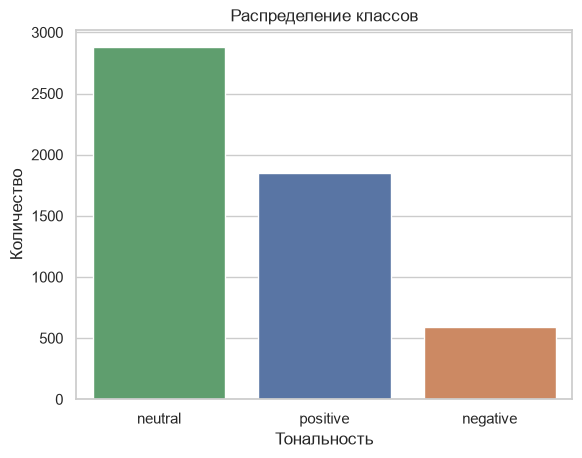

In [8]:
order = df['sentiment'].value_counts().index
sns.countplot(data=df, x='sentiment', order=order, hue='sentiment', legend=False)
plt.title('Распределение классов'); plt.xlabel('Тональность'); plt.ylabel('Количество')
plt.show()

## 4. Анализ длины текстов

In [9]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df[['text_length', 'word_count']].describe().round(1)

,text_length,word_count
count,5322.0,5322.0
mean,116.1,20.7
std,56.5,10.3
min,9.0,2.0
25%,71.0,13.0
50%,106.0,19.0
75%,150.0,27.0
max,315.0,81.0


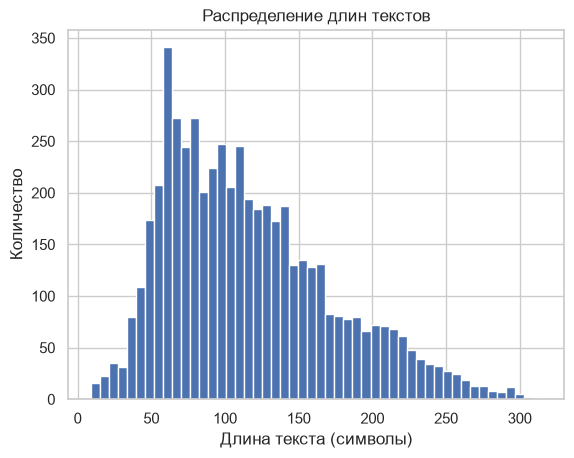

In [10]:
df['text_length'].hist(bins=50)
plt.xlabel('Длина текста (символы)'); plt.ylabel('Количество')
plt.title('Распределение длин текстов'); plt.show()

## 5. Примеры по классам

In [11]:
for s in sorted(df['sentiment'].unique()):
    print(f'[{s}] ' + df.loc[df.sentiment == s, 'text'].iloc[0][:160])

[negative] $ESI on lows, down $1.50 to $2.50 BK a real possibility
[neutral] According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating in Russia .
[positive] The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant mu


## Выводы
- Задача: классификация тональности на 3 класса (negative/neutral/positive).
- `neutral` преобладает (~54%), `negative` редкий (~11%) → метрика **macro F1**.
- Тексты короткие (одно-два предложения).
- Есть тикеры (`$ESI`) и числа — потенциально полезные признаки.